# K-Means - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. Se comparan las métricas internas y se analizan los perfiles obtenidos para las configuraciones seleccionadas.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import kmeans_metrics, plot_clustering_metrics, analyze_clusters, fit_clustering_model, save_clustering_metrics
import pandas as pd
import time

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")

In [3]:
# Variables utilizadas para clustering
X = df_scaled.drop(columns=["user_id"], errors="ignore")

## Evaluación del número de clusters


In [4]:
resultados_kmeans = kmeans_metrics(X)

In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_kmeans,
    model_name="kmeans",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

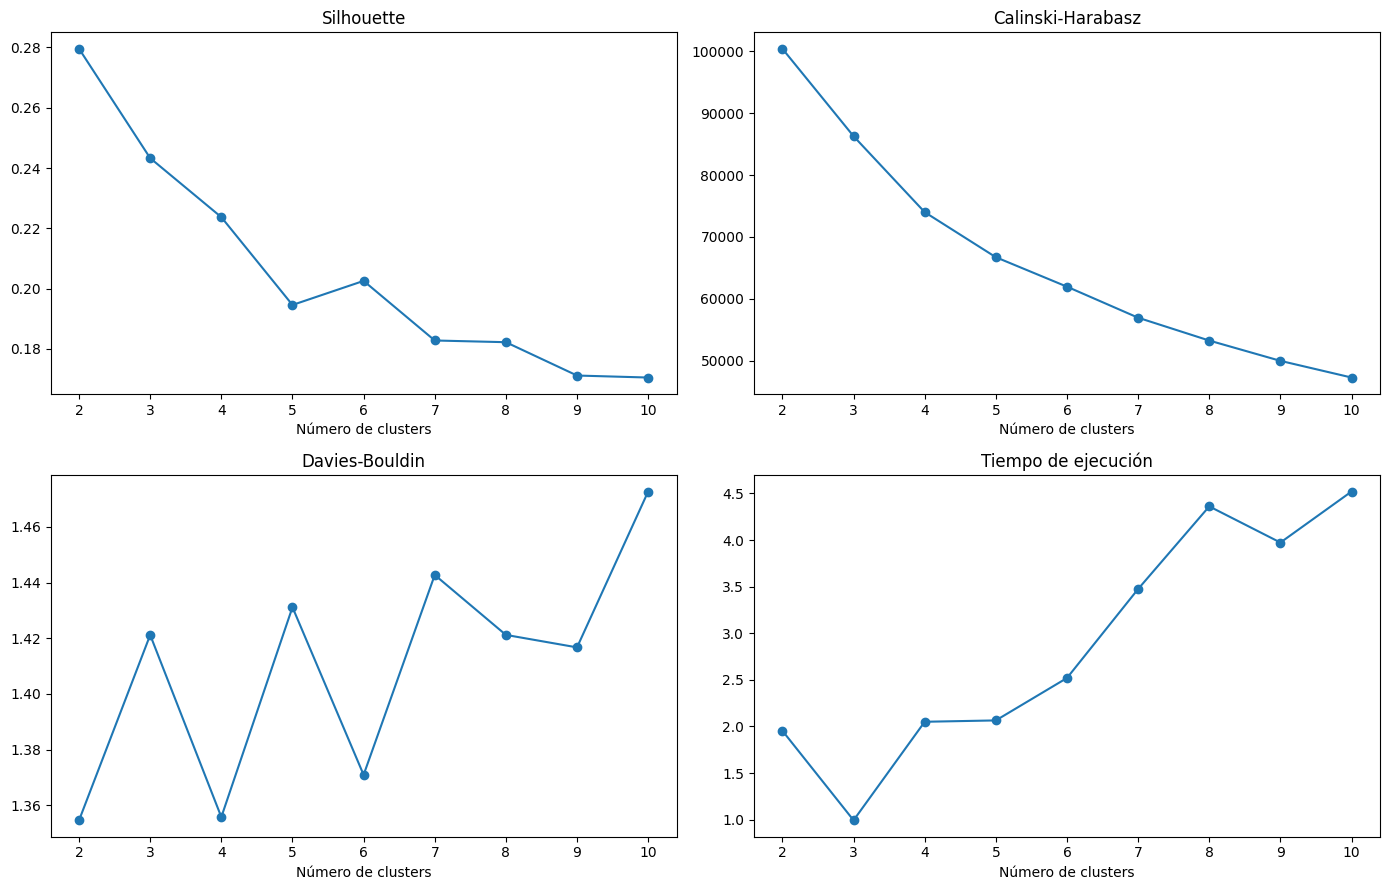

In [5]:
plot_clustering_metrics(resultados_kmeans)

In [6]:
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

## Ajuste final y perfil de los clusters


In [8]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=4,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="user_id"
)

print(f"K-MEANS CON k = {4}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 4

Tamaño de los clusters:


cluster
0    73452
1    55645
2    34441
3    42671
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    35.62
1    26.98
2    16.70
3    20.69
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,20.832,8.138,12.572,5.427,15.977,11.111,59.543,29.292,11.985,0.324,0.676
1,10.198,33.247,12.768,5.525,8.967,6.361,129.517,45.923,14.396,0.614,0.386
2,11.750,15.970,5.743,2.296,10.162,7.166,28.905,15.856,7.977,0.563,0.437
3,23.809,5.088,5.164,2.216,17.496,12.600,17.152,11.160,6.484,0.277,0.723


- Cluster 0 – Compradores esporádicos de cesta grande: clientes con una frecuencia de compra relativamente baja y mayor tiempo desde la última compra, pero que realizan pedidos de tamaño elevado. Presentan una variedad considerable de productos y una baja proporción de recompras, lo que indica un comportamiento más exploratorio y menos rutinario.
- Cluster 1 – Clientes frecuentes y fieles: agrupa a los clientes con mayor frecuencia de compra, pedidos de gran tamaño y menor tiempo entre compras. También destacan por adquirir una elevada variedad de productos y presentar la mayor proporción de recompras. Representan el segmento de clientes más activos y vinculados.
- Cluster 2 – Clientes recurrentes de cesta pequeña: clientes con buena recencia y una frecuencia de compra moderada-alta, pero con cestas de menor tamaño. Compran de forma relativamente regular y presentan una elevada proporción de recompras, lo que refleja un comportamiento recurrente centrado en un conjunto más reducido de productos.
- Cluster 3 – Clientes ocasionales o poco activos: presenta la menor frecuencia de compra, las cestas más pequeñas y el mayor intervalo entre pedidos. Además, estos clientes compran una menor cantidad de productos diferentes y muestran una baja proporción de recompras. Se trata, por tanto, del segmento con menor nivel de actividad y vinculación.

In [9]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=2,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="user_id"
)

print(f"K-MEANS CON k = {2}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 2

Tamaño de los clusters:


cluster
0    110867
1     95342
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    53.76
1    46.24
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,21.123,6.775,7.898,3.387,15.970,11.354,30.654,17.406,8.582,0.322,0.678
1,12.340,25.842,12.339,5.289,10.473,7.298,103.936,39.851,13.440,0.561,0.439


- Cluster 0 – Clientes ocasionales o de baja vinculación: presentan una frecuencia de compra reducida (6,78 pedidos), mayor recencia (21,12 días) y periodos más largos entre compras. Sus cestas son más pequeñas, adquieren menos productos distintos y tienen una proporción de recompra baja (0,32). Su elevado product_variety_ratio se debe principalmente a que realizan pocas compras y repiten relativamente poco los mismos productos.
- Cluster 1 – Clientes activos y recurrentes: realizan compras con mucha mayor frecuencia (25,84 pedidos), presentan mejor recencia (12,34 días) y compran cada menos tiempo. Sus cestas son mayores, adquieren una variedad absoluta mucho más elevada de productos, pasillos y departamentos y presentan una proporción de recompra alta (0,56), mostrando un comportamiento más recurrente y vinculado.

In [10]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=6,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_original,
    id_col="user_id"
)

print(f"K-MEANS CON k = {6}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)


K-MEANS CON k = 6

Tamaño de los clusters:


cluster
0    44355
1    25513
2    26197
3    46993
4    39250
5    23901
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    21.51
1    12.37
2    12.70
3    22.79
4    19.03
5    11.59
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,25.448,5.332,9.863,4.343,18.149,12.811,36.107,20.533,9.906,0.232,0.768
1,8.151,6.921,9.392,3.882,8.874,7.651,40.011,21.795,10.198,0.281,0.719
2,23.171,5.703,3.547,1.499,17.298,12.107,11.379,7.924,5.010,0.363,0.637
3,20.003,12.676,14.004,5.929,15.309,10.213,85.423,37.276,13.383,0.447,0.553
4,8.337,39.421,12.568,5.508,7.833,5.596,142.731,48.339,14.670,0.649,0.351
5,12.859,21.313,5.467,2.258,10.781,7.298,32.261,16.980,8.254,0.656,0.344


- Cluster 0 – Clientes ocasionales de cesta media-grande: presentan una frecuencia de compra baja y una recencia elevada, por lo que llevan más tiempo sin comprar. Sin embargo, realizan pedidos de tamaño relativamente elevado. Su proporción de recompra es baja y presentan una alta variedad relativa de productos, lo que refleja un comportamiento poco recurrente y más exploratorio.
- Cluster 1 – Clientes recientes poco recurrentes: son clientes que han comprado recientemente y presentan intervalos relativamente cortos entre pedidos, aunque su frecuencia de compra sigue siendo reducida. Realizan cestas de tamaño medio y muestran una baja proporción de recompra, por lo que su actividad reciente todavía no se traduce en un comportamiento especialmente fiel.
- Cluster 2 – Clientes ocasionales de cesta pequeña: presentan una frecuencia de compra muy baja, una recencia elevada y pedidos especialmente pequeños. También adquieren pocos productos, pasillos y departamentos distintos, representando uno de los segmentos con menor actividad y diversidad de compra.
- Cluster 3 – Compradores esporádicos de cesta grande: tienen una frecuencia de compra intermedia y una actividad reciente relativamente baja, pero destacan por realizar las cestas de mayor tamaño. También compran una variedad considerable de productos, pasillos y departamentos, mostrando un comportamiento de compra menos frecuente pero más voluminoso.
- Cluster 4 – Clientes frecuentes y fieles: constituye el grupo con mayor frecuencia de compra, buena recencia y los intervalos más cortos entre pedidos. Realizan cestas grandes, adquieren una elevada variedad de productos y presentan una alta proporción de recompras. Representan el segmento de clientes más activos y vinculados.
- Cluster 5 – Clientes recurrentes de cesta pequeña: presentan una frecuencia de compra alta, buena recencia y una elevada proporción de recompra. Sin embargo, realizan cestas pequeñas y compran un conjunto más reducido de productos, lo que refleja un comportamiento habitual y recurrente centrado en productos concretos.